# 10b_model_enriched.ipynb
Modelo 10: RS embeddings (64d) + Review text embeddings (384d) + RAWG features (12d).
Compara tres configuraciones de features para cuantificar el aporte de los datos RAWG.

**Features extras RAWG:** rawg_rating, metacritic, playtime_avg_h, ratings_count,
n_platforms, n_genres, n_developers, n_publishers, esrb_ordinal + indicadores de missingness.

In [1]:
import pandas as pd
import numpy as np
import json
import ast
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

USERMAP     = "../Data/user2idx.json"
ITEMMAP     = "../Data/item2idx.json"
ITEM_EMB_RS = "../Data/item_embeddings_rs.npy"
REVIEW_EMB  = "../Data/review_text_embeddings.npy"
RAWG_CSV    = "../Data/rawg_enriched.csv"
STEAM_GAMES = "../Data/steam_games.json"
REVIEWS     = "../Data/australian_user_reviews.json"

with open(USERMAP, "r") as f: user2idx = {k: int(v) for k, v in json.load(f).items()}
with open(ITEMMAP, "r") as f: item2idx = {k: int(v) for k, v in json.load(f).items()}

print("Imports and mappings loaded")
print(f"Items en modelo: {len(item2idx)}")

Imports and mappings loaded
Items en modelo: 3682


## Cargar embeddings (RS + Review Text)

In [2]:
item_emb_rs = np.load(ITEM_EMB_RS)   # (N, 64)
review_emb  = np.load(REVIEW_EMB)    # (N, 384)
N = item_emb_rs.shape[0]

assert item_emb_rs.shape[0] == review_emb.shape[0]
print(f"RS embeddings:     {item_emb_rs.shape}")
print(f"Review embeddings: {review_emb.shape}")

RS embeddings:     (3682, 64)
Review embeddings: (3682, 384)


## Construir features RAWG

Extraemos 12 features numericas de los datos descargados:
`rawg_rating`, `rawg_ratings_count`, `playtime_avg_h`, `metacritic`,
`n_platforms`, `n_genres_rawg`, `n_developers`, `n_publishers`, `esrb_ordinal`,
mas indicadores de missingness para rating y metacritic.

In [3]:
df_rawg = pd.read_csv(RAWG_CSV)
df_rawg = df_rawg.drop_duplicates(subset=["item_idx"], keep="last")
df_rawg = df_rawg.set_index("item_idx")

# Deserializar columnas de listas guardadas como strings
def parse_list(x):
    if isinstance(x, list): return x
    if isinstance(x, str) and x.startswith("["):
        try: return ast.literal_eval(x)
        except: return []
    return []

for col in ["genres", "platforms", "developers", "publishers", "tags"]:
    if col in df_rawg.columns:
        df_rawg[col] = df_rawg[col].apply(parse_list)

ESRB_ORDER = {"Everyone": 1, "Everyone 10+": 2, "Teen": 3, "Mature": 4, "Adults Only": 5}

RAWG_FEAT_NAMES = [
    "rawg_found", "rawg_rating", "rawg_rating_miss",
    "metacritic", "metacritic_miss",
    "playtime_log", "ratings_cnt_log",
    "n_platforms", "n_genres_rawg", "n_developers", "n_publishers",
    "esrb_ordinal"
]

def build_rawg_features(idx: int) -> list:
    if idx not in df_rawg.index:
        return [0.] * 12
    r = df_rawg.loc[idx]
    found       = 1.0 if r.get("rawg_id") is not None else 0.0
    rating      = float(r["rawg_rating"])       if pd.notna(r.get("rawg_rating"))        else -1.0
    rating_miss = 0.0 if pd.notna(r.get("rawg_rating")) else 1.0
    mc          = float(r["metacritic"])         if pd.notna(r.get("metacritic"))         else -1.0
    mc_miss     = 0.0 if pd.notna(r.get("metacritic")) else 1.0
    play        = np.log1p(float(r["playtime_avg_h"]))      if pd.notna(r.get("playtime_avg_h"))      else 0.0
    rcnt        = np.log1p(float(r["rawg_ratings_count"]))  if pd.notna(r.get("rawg_ratings_count"))  else 0.0
    n_plat  = float(len(parse_list(r.get("platforms", []))))
    n_genre = float(len(parse_list(r.get("genres", []))))
    n_dev   = float(len(parse_list(r.get("developers", []))))
    n_pub   = float(len(parse_list(r.get("publishers", []))))
    esrb    = float(ESRB_ORDER.get(r.get("esrb_rating", ""), 0))
    return [found, rating, rating_miss, mc, mc_miss, play, rcnt,
            n_plat, n_genre, n_dev, n_pub, esrb]

rawg_features = np.array([build_rawg_features(i) for i in range(N)], dtype=np.float32)
print(f"RAWG features shape: {rawg_features.shape}")
print(f"Juegos con RAWG match: {int(rawg_features[:,0].sum())} / {N} ({rawg_features[:,0].mean()*100:.1f}%)")

RAWG features shape: (3682, 12)
Juegos con RAWG match: 3195 / 3682 (86.8%)


## Variable objetivo (total reviews por juego)

In [4]:
reviews_raw = []
with open(REVIEWS, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line: continue
        reviews_raw.append(ast.literal_eval(line))

all_interactions = []
for r in reviews_raw:
    for rev in r.get("reviews", []):
        if isinstance(rev, dict) and "item_id" in rev and rev["item_id"] in item2idx:
            all_interactions.append({"user_id": r["user_id"],
                                     "item_idx": item2idx[rev["item_id"]]})

df_inter = pd.DataFrame(all_interactions)
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")
y = target_df.set_index("item_idx").reindex(range(N), fill_value=0)["total_reviews"].values

print(f"Target shape: {y.shape}  |  range: {y.min()} - {y.max()}  |  media: {y.mean():.2f}")

Target shape: (3682,)  |  range: 1 - 3759  |  media: 16.11


## Matrices de features y split temporal

Tres configuraciones:
- **A** RS only (64d) — baseline
- **B** RS + Review text (448d) — igual que modelo 09
- **C** RS + Reviews + RAWG (460d) — este modelo

In [5]:
X_rs   = item_emb_rs                                          # (N, 64)
X_09   = np.hstack([item_emb_rs, review_emb])                 # (N, 448)
X_full = np.hstack([item_emb_rs, review_emb, rawg_features])  # (N, 460)

print(f"X_rs   shape: {X_rs.shape}")
print(f"X_09   shape: {X_09.shape}")
print(f"X_full shape: {X_full.shape}")

# Metadatos de fecha para split temporal
games = []
with open(STEAM_GAMES, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line: continue
        games.append(ast.literal_eval(line))

df_meta = pd.json_normalize(games)
df_meta["item_idx"] = df_meta["id"].map(item2idx)
df_meta = df_meta.dropna(subset=["item_idx"])
df_meta["item_idx"] = df_meta["item_idx"].astype(int)
df_meta["release_date_parsed"] = pd.to_datetime(df_meta["release_date"], errors="coerce")

cutoff = pd.Timestamp("2016-01-01")
item_dates = df_meta.set_index("item_idx")["release_date_parsed"].reindex(range(N))

train_mask = np.array([pd.notna(d) and d < cutoff  for d in item_dates])
test_mask  = np.array([pd.notna(d) and d >= cutoff for d in item_dates])

print(f"\nSplit temporal (corte: {cutoff.date()}):")
print(f"  Train: {train_mask.sum()} juegos")
print(f"  Test:  {test_mask.sum()} juegos")

X_rs   shape: (3682, 64)
X_09   shape: (3682, 448)
X_full shape: (3682, 460)



Split temporal (corte: 2016-01-01):
  Train: 2621 juegos
  Test:  486 juegos


## Imputacion de faltantes RAWG

`rawg_rating` (82% cobertura) y `metacritic` (36.5%) tienen valores faltantes codificados como -1.
Los reemplazamos con la **mediana del train set** para evitar data leakage.

In [6]:
IMPUTE_COLS  = [1, 3]   # rawg_rating=1, metacritic=3  (offset dentro de RAWG)
IMPUTE_NAMES = ["rawg_rating", "metacritic"]
RAWG_OFFSET  = 64 + 384  # despues de RS + Review

def impute_with_train_median(X, train_mask, impute_cols=IMPUTE_COLS):
    X_imp = X.copy()
    for ci in impute_cols:
        col = RAWG_OFFSET + ci
        train_vals = X_imp[train_mask, col]
        valid      = train_vals[train_vals != -1.0]
        median_val = float(np.median(valid)) if len(valid) > 0 else 0.0
        X_imp[X_imp[:, col] == -1.0, col] = median_val
    return X_imp

X_full_imp = impute_with_train_median(X_full, train_mask)

print("Imputacion completada:")
for ci, nm in zip(IMPUTE_COLS, IMPUTE_NAMES):
    col = RAWG_OFFSET + ci
    n_before = (X_full[:, col] == -1).sum()
    n_after  = (X_full_imp[:, col] == -1).sum()
    print(f"  {nm}: {n_before} valores -1 -> {n_after} restantes")

Imputacion completada:
  rawg_rating: 576 valores -1 -> 0 restantes
  metacritic: 2030 valores -1 -> 0 restantes


## Funciones de entrenamiento

In [7]:
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100 if mask.sum() > 0 else np.nan
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

# ─── Optuna: Busqueda de Hiperparametros ─────────────────────────────────────
# Optimizamos sobre la configuracion full (RS+Reviews+RAWG = X_full_imp)
import optuna
from sklearn.metrics import mean_squared_error as _mse_opt_
optuna.logging.set_verbosity(optuna.logging.WARNING)

_n_tr      = int(train_mask.sum())
_X_tr_raw  = X_full_imp[train_mask]
_y_tr_raw  = y[train_mask]
_vsp       = max(10, int(_n_tr * 0.8))
_X_tr, _X_val = _X_tr_raw[:_vsp], _X_tr_raw[_vsp:]
_y_tr, _y_val = _y_tr_raw[:_vsp], _y_tr_raw[_vsp:]

def _objective(trial):
    _p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 800),
        learning_rate    = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        random_state=42, verbosity=0,
    )
    _m = XGBRegressor(**_p)
    _m.fit(_X_tr, _y_tr)
    return float(_mse_opt_(_y_val, _m.predict(_X_val)) ** 0.5)

_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42))
_study.optimize(_objective, n_trials=50, show_progress_bar=True)

best_params = {**_study.best_params, 'random_state': 42, 'verbosity': 0}
print(f"\nMejores hiperparametros (val RMSE={_study.best_value:.2f}):")
for _k, _v in best_params.items():
    print(f"  {_k}: {_v}")

def train_eval(X, y, tr_mask, te_mask, label=""):
    Xtr, ytr = X[tr_mask], y[tr_mask]
    Xte, yte = X[te_mask], y[te_mask]
    mdl = XGBRegressor(**best_params)
    mdl.fit(Xtr, ytr)
    pred = mdl.predict(Xte)
    m = calculate_metrics(yte, pred)
    print(f"{label:<32s}  R2={m['R2']:+.4f}  RMSE={m['RMSE']:.2f}  MAE={m['MAE']:.2f}")
    return mdl, pred, yte, m

print("Funciones definidas OK")

  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 1.63352:   0%|          | 0/50 [00:02<?, ?it/s]

Best trial: 0. Best value: 1.63352:   2%|▏         | 1/50 [00:02<02:06,  2.58s/it]

Best trial: 1. Best value: 0.607295:   2%|▏         | 1/50 [00:11<02:06,  2.58s/it]

Best trial: 1. Best value: 0.607295:   4%|▍         | 2/50 [00:11<05:13,  6.52s/it]

...

Best trial: 41. Best value: 0.603594:  98%|█████████▊| 49/50 [06:03<00:07,  7.19s/it]

Best trial: 41. Best value: 0.603594:  98%|█████████▊| 49/50 [06:06<00:07,  7.19s/it]

Best trial: 41. Best value: 0.603594: 100%|██████████| 50/50 [06:06<00:00,  5.82s/it]

Best trial: 41. Best value: 0.603594: 100%|██████████| 50/50 [06:06<00:00,  7.33s/it]


Mejores hiperparametros (val RMSE=0.60):
  n_estimators: 750
  learning_rate: 0.024475473266049978
  max_depth: 7
  min_child_weight: 1
  subsample: 0.8609628308011623
  colsample_bytree: 0.9143737211682635
  gamma: 0.006040111614590851
  random_state: 42
  verbosity: 0
Funciones definidas OK


## Comparacion de configuraciones (temporal split)

In [8]:
print("="*70)
print("TEMPORAL SPLIT — comparacion de configuraciones")
print("="*70)

model_rs,   pred_rs,   yte_rs,   m_rs   = train_eval(X_rs,       y, train_mask, test_mask, "A) RS only (64d)")
model_09,   pred_09,   yte_09,   m_09   = train_eval(X_09,       y, train_mask, test_mask, "B) RS+Reviews (448d)")
model_full, pred_full, yte_full, m_full = train_eval(X_full_imp,  y, train_mask, test_mask, "C) RS+Reviews+RAWG (460d)")

delta_r2   = m_full["R2"]   - m_09["R2"]
delta_rmse = m_09["RMSE"]   - m_full["RMSE"]
print(f"\nMejora RAWG sobre RS+Reviews:")
print(f"  Delta R2:   {delta_r2:+.4f}")
print(f"  Delta RMSE: {delta_rmse:+.2f} (positivo = mejora)")

TEMPORAL SPLIT — comparacion de configuraciones


A) RS only (64d)                  R2=+0.6294  RMSE=34.64  MAE=3.74


B) RS+Reviews (448d)              R2=+0.8452  RMSE=22.39  MAE=3.28


C) RS+Reviews+RAWG (460d)         R2=+0.9379  RMSE=14.18  MAE=2.52

Mejora RAWG sobre RS+Reviews:
  Delta R2:   +0.0927
  Delta RMSE: +8.21 (positivo = mejora)


## Time Series Cross-Validation

In [9]:
cutoff_windows = [
    ("2013-07-01", "2014-01-01"),
    ("2014-01-01", "2014-07-01"),
    ("2014-07-01", "2015-01-01"),
    ("2015-01-01", "2015-07-01"),
    ("2015-07-01", "2016-01-01"),
]

ts_results = []
print("="*70); print("TIME SERIES CV — RS+Reviews+RAWG"); print("="*70)

for i, (tc, sc) in enumerate(cutoff_windows, 1):
    tc, sc = pd.Timestamp(tc), pd.Timestamp(sc)
    tmask  = np.array([pd.notna(d) and d < tc                  for d in item_dates])
    emask  = np.array([pd.notna(d) and d >= tc and d < sc      for d in item_dates])
    if emask.sum() < 10: continue

    Xtr  = impute_with_train_median(X_full, tmask)[tmask]
    Xte  = impute_with_train_median(X_full, tmask)[emask]
    ytr, yte = y[tmask], y[emask]

    mdl = XGBRegressor(**best_params)
    mdl.fit(Xtr, ytr); m = calculate_metrics(yte, mdl.predict(Xte))
    m.update({"fold": i, "train": int(tmask.sum()), "test": int(emask.sum())})
    ts_results.append(m)
    print(f"Fold {i} | train={int(tmask.sum())} test={int(emask.sum())} | R2={m['R2']:.4f}  RMSE={m['RMSE']:.2f}")

df_ts = pd.DataFrame(ts_results)
print(f"\nTSCV promedio:  R2={df_ts['R2'].mean():.4f} +/- {df_ts['R2'].std():.4f}")
print(f"TSCV promedio: RMSE={df_ts['RMSE'].mean():.2f} +/- {df_ts['RMSE'].std():.2f}")

TIME SERIES CV — RS+Reviews+RAWG


Fold 1 | train=1110 test=222 | R2=0.7927  RMSE=35.89


Fold 2 | train=1332 test=280 | R2=0.9788  RMSE=5.42


Fold 3 | train=1612 test=299 | R2=0.9215  RMSE=5.03


Fold 4 | train=1911 test=343 | R2=0.4682  RMSE=19.32


Fold 5 | train=2254 test=367 | R2=0.6779  RMSE=16.11

TSCV promedio:  R2=0.7678 +/- 0.2041
TSCV promedio: RMSE=16.36 +/- 12.63


## K-Fold Cross-Validation

In [10]:
valid_mask = np.array([pd.notna(d) for d in item_dates])
X_v = X_full_imp[valid_mask]; y_v = y[valid_mask]

kfold_results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("="*60); print("K-FOLD CV (5 folds) — RS+Reviews+RAWG"); print("="*60)

for fi, (tri, tei) in enumerate(kf.split(X_v), 1):
    mdl = XGBRegressor(**best_params)
    mdl.fit(X_v[tri], y_v[tri])
    m = calculate_metrics(y_v[tei], mdl.predict(X_v[tei]))
    m["fold"] = fi; kfold_results.append(m)
    print(f"Fold {fi}  R2={m['R2']:.4f}  RMSE={m['RMSE']:.2f}")

df_kf = pd.DataFrame(kfold_results)
print(f"\nKFold promedio: R2={df_kf['R2'].mean():.4f} +/- {df_kf['R2'].std():.4f}")
print(f"KFold promedio: RMSE={df_kf['RMSE'].mean():.2f} +/- {df_kf['RMSE'].std():.2f}")

K-FOLD CV (5 folds) — RS+Reviews+RAWG


Fold 1  R2=0.5921  RMSE=38.26


Fold 2  R2=0.4636  RMSE=113.41


Fold 3  R2=0.5849  RMSE=20.82


Fold 4  R2=0.3668  RMSE=140.14


Fold 5  R2=0.5285  RMSE=27.88

KFold promedio: R2=0.5072 +/- 0.0940
KFold promedio: RMSE=68.10 +/- 54.74


## Feature Importance por bloque

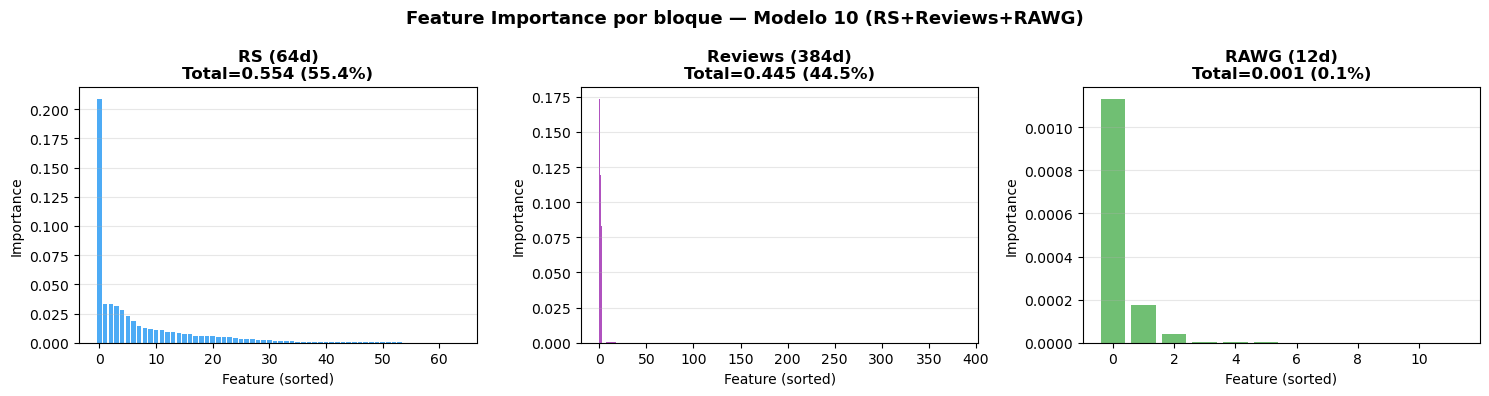


=== CONTRIBUCION POR BLOQUE ===
  RS (64d)            : 0.5536  (55.4%)
  Reviews (384d)      : 0.4451  (44.5%)
  RAWG (12d)          : 0.0014  (0.1%)

Top RAWG features:
  playtime_log             : 0.001132  ####################
  rawg_rating_miss         : 0.000175  ###
  ratings_cnt_log          : 0.000042  
  n_platforms              : 0.000002  
  rawg_rating              : 0.000002  
  metacritic               : 0.000001  
  n_genres_rawg            : 0.000001  
  metacritic_miss          : 0.000001  
  n_developers             : 0.000000  
  esrb_ordinal             : 0.000000  
  n_publishers             : 0.000000  
  rawg_found               : 0.000000  


In [11]:
imp        = model_full.feature_importances_  # (460,)
imp_rs     = imp[:64]
imp_review = imp[64:448]
imp_rawg   = imp[448:]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#2196F3", "#9C27B0", "#4CAF50"]
labels = ["RS (64d)", "Reviews (384d)", "RAWG (12d)"]
data   = [imp_rs, imp_review, imp_rawg]

for ax, d, c, lab in zip(axes, data, colors, labels):
    ax.bar(range(len(d)), sorted(d, reverse=True), color=c, alpha=0.8)
    ax.set_title(f"{lab}\nTotal={d.sum():.3f} ({d.sum()/imp.sum()*100:.1f}%)", fontweight="bold")
    ax.set_xlabel("Feature (sorted)"); ax.set_ylabel("Importance")
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Feature Importance por bloque — Modelo 10 (RS+Reviews+RAWG)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("\n=== CONTRIBUCION POR BLOQUE ===")
for d, lab in zip(data, labels):
    print(f"  {lab:<20s}: {d.sum():.4f}  ({d.sum()/imp.sum()*100:.1f}%)")

# Top features RAWG
print("\nTop RAWG features:")
for nm, v in sorted(zip(RAWG_FEAT_NAMES, imp_rawg), key=lambda x: x[1], reverse=True):
    bar = "#" * int(v / imp_rawg.max() * 20)
    print(f"  {nm:<25s}: {v:.6f}  {bar}")

## Visualizacion: prediccion vs real

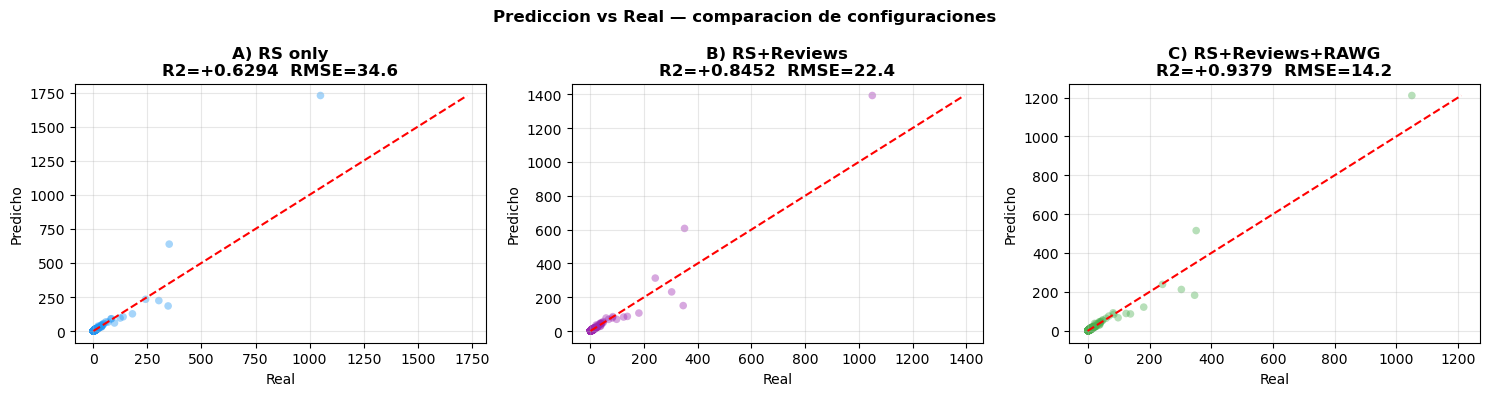

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    (pred_rs,   yte_rs,   m_rs,   "A) RS only",         "#2196F3"),
    (pred_09,   yte_09,   m_09,   "B) RS+Reviews",      "#9C27B0"),
    (pred_full, yte_full, m_full, "C) RS+Reviews+RAWG", "#4CAF50"),
]
for ax, (pred, yte, m, lab, col) in zip(axes, configs):
    ax.scatter(yte, pred, alpha=0.4, s=30, color=col, edgecolors="none")
    lim = [min(yte.min(), pred.min()), max(yte.max(), pred.max())]
    ax.plot(lim, lim, "r--", lw=1.5)
    ax.set_title(f"{lab}\nR2={m['R2']:+.4f}  RMSE={m['RMSE']:.1f}", fontweight="bold")
    ax.set_xlabel("Real"); ax.set_ylabel("Predicho")
    ax.grid(True, alpha=0.3)
plt.suptitle("Prediccion vs Real — comparacion de configuraciones", fontweight="bold")
plt.tight_layout(); plt.show()

## Guardar resultados

In [13]:
import sys, os; sys.path.insert(0, ".")
from results_tracker import save_result, print_leaderboard

ablation_note = (f"Ablation: RS={m_rs['R2']:.4f}, "
                 f"09={m_09['R2']:.4f}, full={m_full['R2']:.4f}")

save_result(
    model_id   = "10",
    model_name = "RS + Reviews + RAWG",
    features   = "RS clean (64d) + Review text (384d) + RAWG features (12d)",
    embeddings = "clean",
    metrics = {
        "r2_temporal":    m_full["R2"],
        "rmse_temporal":  m_full["RMSE"],
        "mae_temporal":   m_full["MAE"],
        "mape_temporal":  m_full["MAPE"],
        "r2_tscv":        df_ts["R2"].mean(),
        "r2_tscv_std":    df_ts["R2"].std(),
        "rmse_tscv":      df_ts["RMSE"].mean(),
        "rmse_tscv_std":  df_ts["RMSE"].std(),
        "r2_kfold":       df_kf["R2"].mean(),
        "r2_kfold_std":   df_kf["R2"].std(),
        "rmse_kfold":     df_kf["RMSE"].mean(),
        "rmse_kfold_std": df_kf["RMSE"].std(),
    },
    notes = ablation_note,
)
print_leaderboard()

 ID  Modelo                         R2 test     RMSE     MAE   MAPE%   R2 TSCV  R2 KFold
[10]  RS + Reviews + RAWG             0.9379    14.18    2.52    29.3    0.7678    0.5072
[09]  RS + Review Text                0.9066    17.38    3.00    28.2    0.8633    0.3030
[03]  RS Embeddings Only              0.5248    39.22    5.84     0.5    0.6651    0.3747
[08]  Hybrid Collab-Content           0.4489    42.24    5.88     0.4    0.3747    0.4410
[04]  Metadata Only                   0.0653    55.00   19.62     8.3   -0.5163    0.0599
[06]  Review Text Emb                -0.0001    56.90   18.22     8.2   -0.1168   -0.0001
[05]  RS + Metadata                  -0.2096    62.57    9.23     0.5   -0.9298   -0.3642
[07]  Tag Embeddings                -127.2421    65.09   14.09     4.6  -22.5516   -0.0710
